# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [19]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [20]:
# Load the prepared dataset from Phase 3
# Update this path only if your CSV is stored somewhere else.
DATA_PATH = 'data/california_housing_phase3.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 20640 rows x 12 columns


,MedianIncome,HouseAge,AverageRooms,AverageBedrooms,Population,AverageOccupancy,Latitude,Longitude,RoomsPerOccupant,BedroomRoomRatio,PopulationPerRoom,MedianHouseValue
0,2.541006,0.982143,1.347665,-0.424488,-1.325821,-0.497871,1.052548,-1.327835,1.337638,-1.154776,-1.227312,4.526
1,2.541006,-0.607019,0.749027,-1.070004,1.389936,-1.142781,1.043185,-1.322844,1.709811,-0.989764,0.622212,3.585
2,2.085156,1.856182,2.394098,0.192534,-1.098528,-0.140910,1.038503,-1.332827,1.711435,-1.460845,-1.152302,3.521
3,1.111288,1.856182,0.411358,0.187723,-1.017539,-0.508882,1.038503,-1.337818,0.589576,-0.475999,-0.955357,3.413
4,0.027262,1.856182,0.784108,0.287439,-1.008395,-1.039145,1.038503,-1.337818,1.581678,-0.697598,-0.987994,3.422


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [7]:
# Select and document the modelling techniques here.

modelling_techniques = {
    "problem_type": "Regression",
    "target_variable": "MedianHouseValue",
    "candidate_models": [
        {
            "name": "Linear Regression",
            "library": "sklearn.linear_model.LinearRegression",
            "justification": "A simple regression model that is easy to interpret and useful for comparison.",
            "assumptions": "Assumes a roughly linear relationship between features and target. It may not capture complex non-linear patterns well."
        },
        {
            "name": "Random Forest Regressor",
            "library": "sklearn.ensemble.RandomForestRegressor",
            "justification": "Works well on tabular data, captures non-linear relationships, and is robust to outliers and feature interactions.",
            "assumptions": "Makes few statistical assumptions and handles non-linear patterns effectively."
        },
        {
            "name": "Gradient Boosting Regressor",
            "library": "sklearn.ensemble.GradientBoostingRegressor",
            "justification": "Often performs strongly on structured regression problems by improving weak learners repeatedly.",
            "assumptions": "Makes few assumptions and can model complex patterns."
        }
    ]
}

print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print("\nCandidate Models:")
for model in modelling_techniques["candidate_models"]:
    print(f"\n- {model['name']}")
    print(f"  Library: {model['library']}")
    print(f"  Justification: {model['justification']}")
    print(f"  Assumptions: {model['assumptions']}")

Problem Type: Regression
Target Variable: MedianHouseValue

Candidate Models:

- Linear Regression
  Library: sklearn.linear_model.LinearRegression
  Justification: A simple regression model that is easy to interpret and useful for comparison.
  Assumptions: Assumes a roughly linear relationship between features and target. It may not capture complex non-linear patterns well.

- Random Forest Regressor
  Library: sklearn.ensemble.RandomForestRegressor
  Justification: Works well on tabular data, captures non-linear relationships, and is robust to outliers and feature interactions.
  Assumptions: Makes few statistical assumptions and handles non-linear patterns effectively.

- Gradient Boosting Regressor
  Library: sklearn.ensemble.GradientBoostingRegressor
  Justification: Often performs strongly on structured regression problems by improving weak learners repeatedly.
  Assumptions: Makes few assumptions and can model complex patterns.


In [8]:
# Import the specific model classes you plan to use
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [9]:
# Define your test design and split the data.

RANDOM_SEED = 42
TEST_SIZE = 0.2

# Define features (X) and target (y)
TARGET_COL = 'MedianHouseValue' if 'MedianHouseValue' in df.columns else 'MedHouseVal'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Perform the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set: 16512 samples
Test set:     4128 samples
Number of features: 11


In [10]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "5-fold cross-validation",
    "stratified": False,
    "random_seed": RANDOM_SEED,
    "justification": "An 80/20 split provides enough data for training while preserving unseen data for evaluation. "
                     "Regression does not require stratified sampling, and a fixed random seed ensures reliability. "
                     "5-fold cross-validation is used to assess model stability and reduce dependence on a single split."
}
print(test_design)

{'split_ratio': '80/20', 'validation_strategy': '5-fold cross-validation', 'stratified': False, 'random_seed': 42, 'justification': 'An 80/20 split provides enough data for training while preserving unseen data for evaluation. Regression does not require stratified sampling, and a fixed random seed ensures reliability. 5-fold cross-validation is used to assess model stability and reduce dependence on a single split.'}


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [12]:
# Build and train your models.
# Store trained models in a dictionary for easy comparison.

trained_models = {}

# --- Model 1 ---
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
trained_models['Linear Regression'] = model_1

# --- Model 2 ---
model_2 = RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=100)
model_2.fit(X_train, y_train)
trained_models['Random Forest'] = model_2

# --- Model 3 ---
model_3 = GradientBoostingRegressor(random_state=RANDOM_SEED)
model_3.fit(X_train, y_train)
trained_models['Gradient Boosting'] = model_3

print(f"Successfully trained {len(trained_models)} model(s).")

Successfully trained 3 model(s).


In [14]:
# Optional: Hyperparameter tuning with GridSearchCV

# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 10, None],
#     'min_samples_split': [2, 5, 10]
# }
#
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=RANDOM_SEED),
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',  # Change to an appropriate metric
#     n_jobs=-1,
#     verbose=1
# )
# grid_search.fit(X_train, y_train)
#
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best CV score:   {grid_search.best_score_:.4f}")
#
# trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [16]:
# Evaluate and compare all trained models.
# Build a results summary table.

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2
0,Random Forest,0.507955,0.332987,0.803101
1,Gradient Boosting,0.535744,0.368769,0.780968
2,Linear Regression,0.655791,0.478249,0.671811



=== Best Model: Random Forest ===
RMSE: 0.5080
MAE:  0.3330
R2:   0.8031


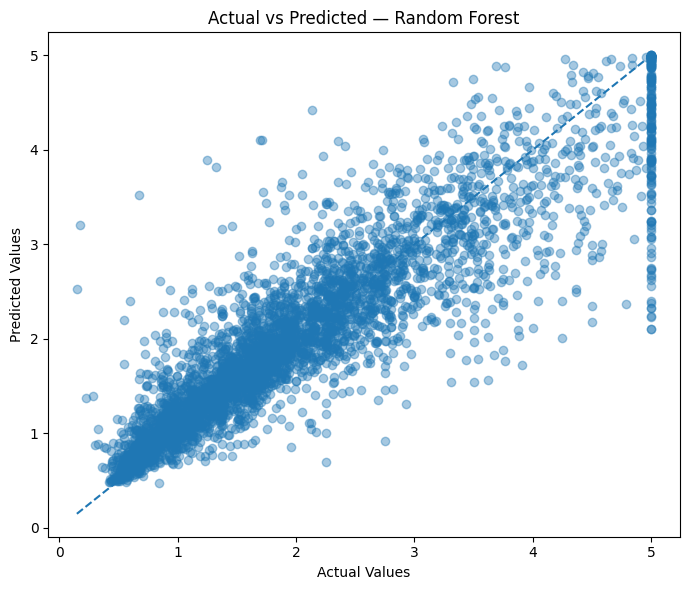

In [17]:
# Visualise results: Actual vs Predicted for the best model

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"R2:   {r2_score(y_test, y_pred_best):.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted — {best_model_name}')

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.tight_layout()
plt.show()

In [21]:
# Cross-validation for the selected best model

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R2 Scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

import joblib

joblib.dump(best_model, "models/best_model.pkl")

Cross-Validation R2 Scores: [0.5112 0.7038 0.7313 0.6205 0.6847]
Mean: 0.6503 (+/- 0.0785)


['models/best_model.pkl']